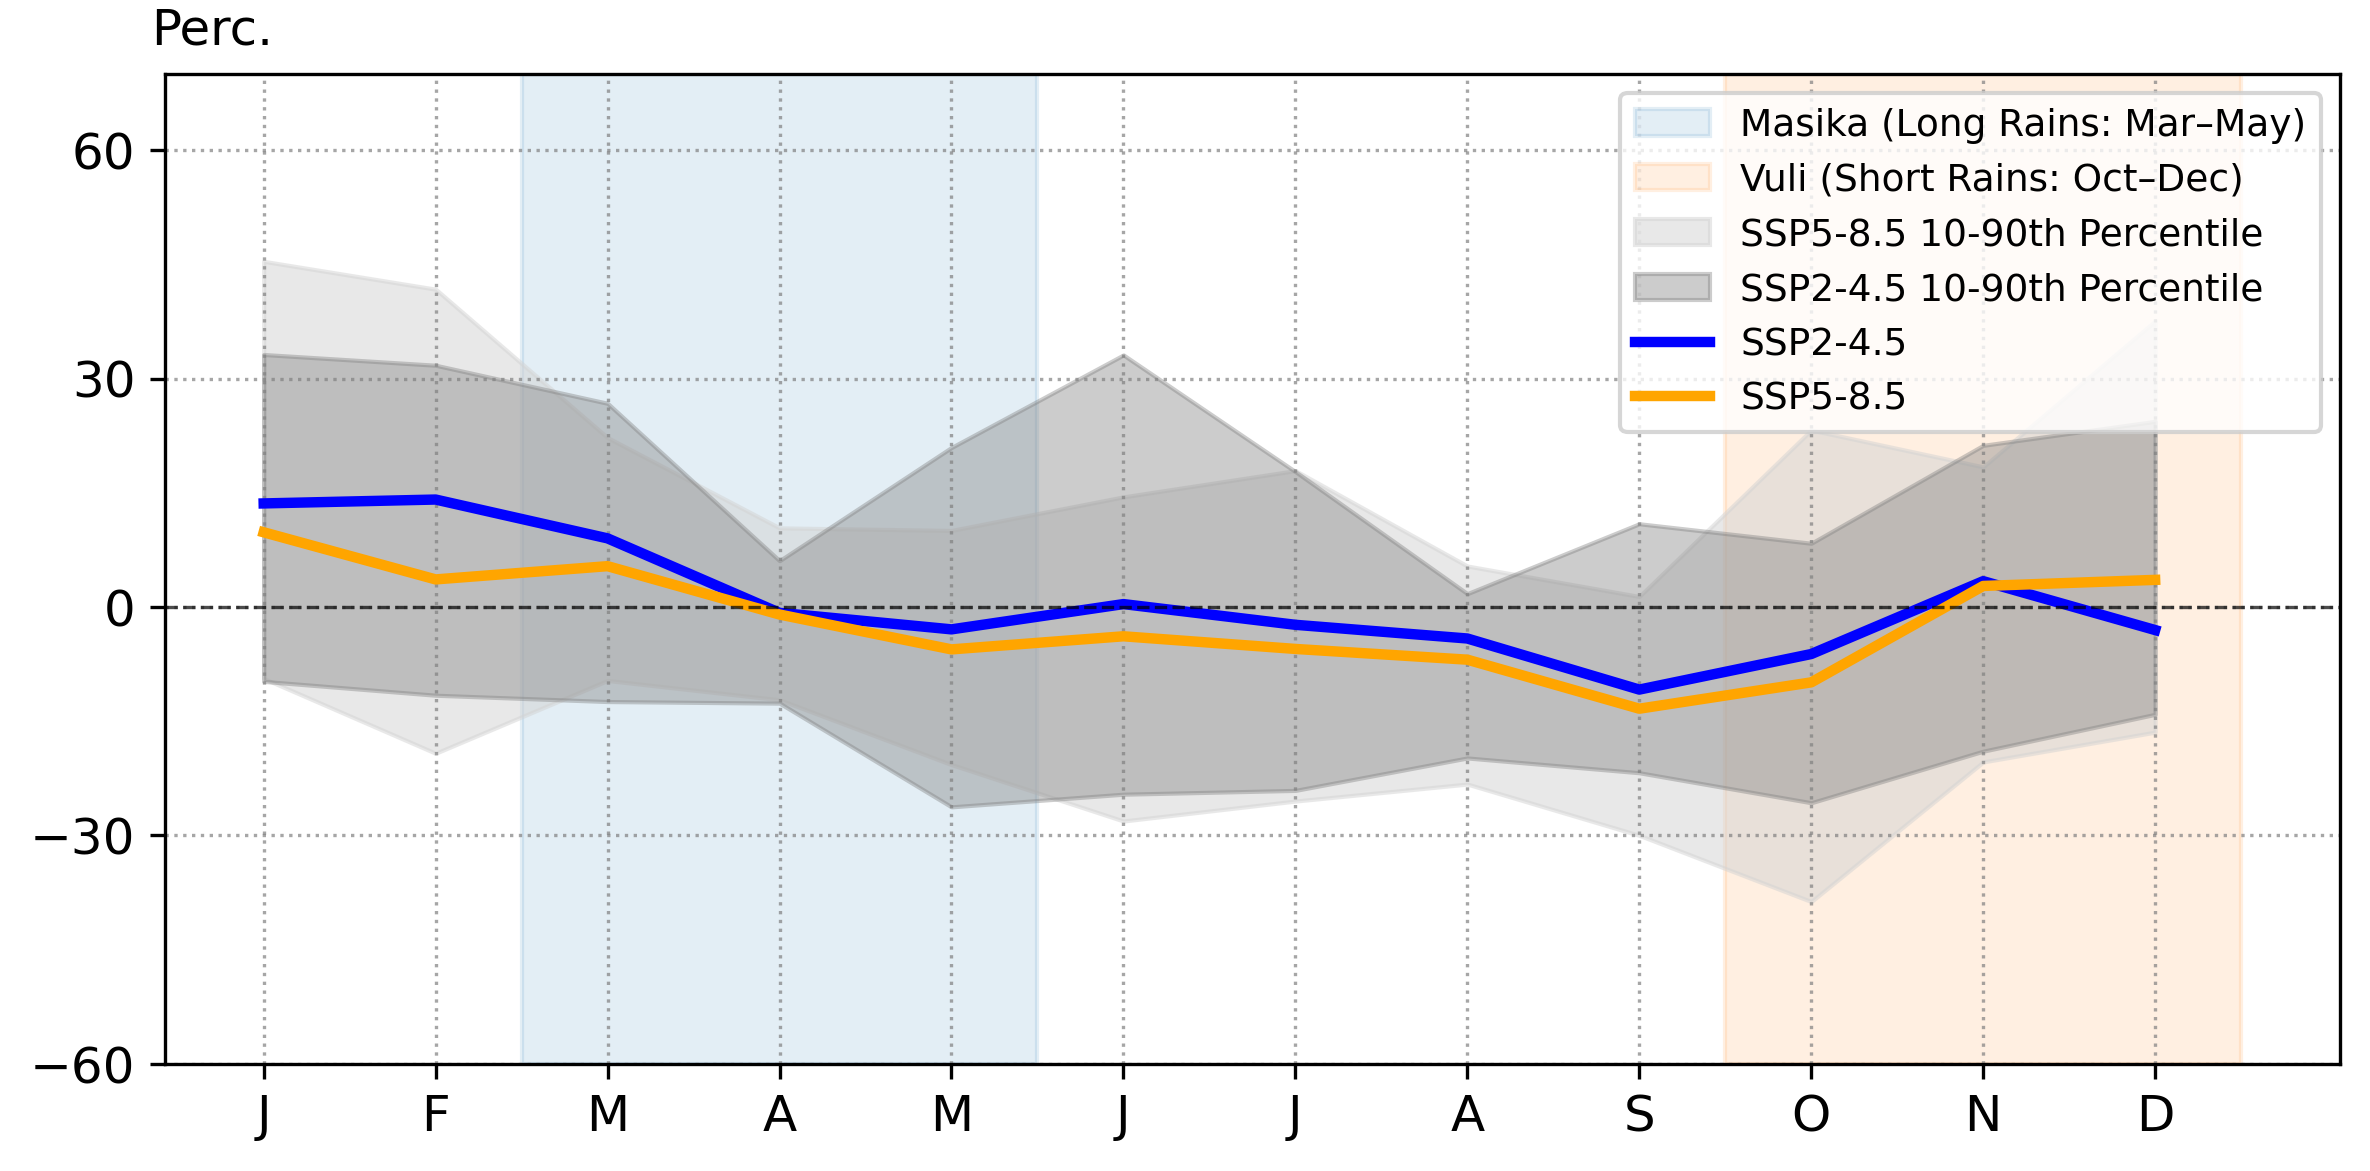

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('climate_data/projections/projected_monthly_mean_rainfall_anomaly.csv')

# Months for x-axis
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
x = np.arange(len(months))

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREY = "#8a9199"
LIGHT_GREY = "#d8dee2"
TEXT = "#333333"

# Add seasonal background shading using axvspan
# Masika (March–May: indices 1.5 to 4.5)
ax.axvspan(1.5, 4.5, color='tab:blue', alpha=0.12, label='Masika (Long Rains: Mar–May)')
# Vuli (October–December: indices 8.5 to 11.5)
ax.axvspan(8.5, 11.5, color='tab:orange', alpha=0.12, label='Vuli (Short Rains: Oct–Dec)')

# Plot shaded percentile ranges
ax.fill_between(x, df['SSP5-8.5 10-90ᵗʰ Percentile Range (low)'], df['SSP5-8.5 10-90ᵗʰ Percentile Range (high)'],
                color='lightgrey', alpha=0.5, label='SSP5-8.5 10-90th Percentile')

ax.fill_between(x, df['SSP2-4.5 10-90ᵗʰ Percentile Range (low)'], df['SSP2-4.5 10-90ᵗʰ Percentile Range (high)'],
                color='gray', alpha=0.4, label='SSP2-4.5 10-90th Percentile')

# Plot median/central estimate lines
ax.plot(x, df['SSP2-4.5'], color='BLUE', linewidth=2.5, label='SSP2-4.5')
ax.plot(x, df['SSP5-8.5'], color='ORANGE', linewidth=2.5, label='SSP5-8.5')

# Axis formatting & styling
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=12)
ax.set_ylabel('Perc.', fontsize=12, loc='top', rotation=0)
ax.yaxis.set_label_coords(0.05, 1.02)

ax.set_ylim(-60, 70)
ax.set_yticks([-60, -30, 0, 30, 60])
ax.tick_params(axis='y', labelsize=12)

# Reference zero-line & grid
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.grid(True, linestyle=':', color='gray', alpha=0.7)

# Legend & Title
ax.legend(loc='upper right', frameon=True, fontsize=9)
#plt.title('Projected Anomaly (%) with Masika & Vuli Seasons', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig('climate_data/projections/figures/projected_anomaly_seasons_plot.png')

Saved mhw_days_intensity_barplot.png


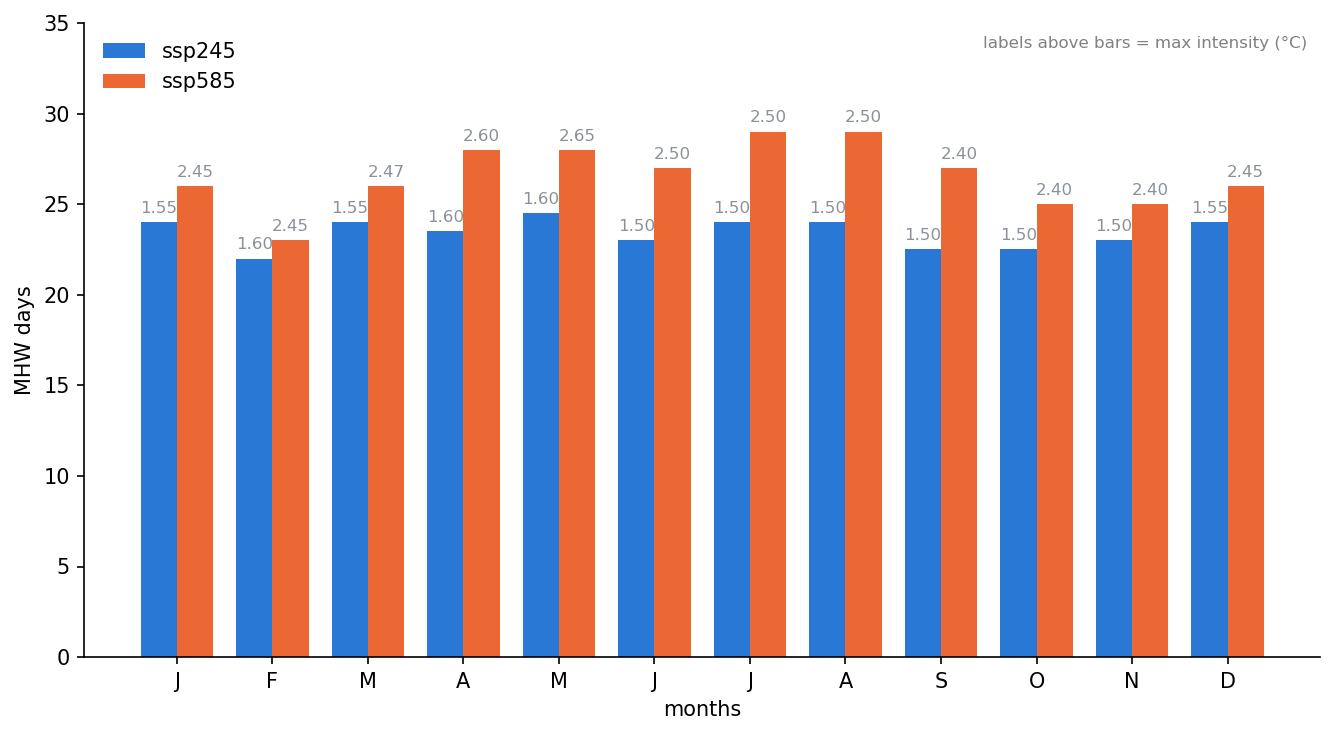

In [3]:
"""
Monthly MHW days (grouped bars) with max intensity labeled above each bar.

Replace the placeholder arrays below with your actual monthly MHW output
(e.g. from your NOAA HadISST / CMIP6 SEAS5 pipeline) before using this
for a manuscript figure. Values here were visually estimated from a
reference figure and are for layout purposes only.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---- data -------------------------------------------------------------
months = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

days_ssp245 = [24, 22, 24, 23.5, 24.5, 23, 24, 24, 22.5, 22.5, 23, 24]
days_ssp585 = [26, 23, 26, 28, 28, 27, 29, 29, 27, 25, 25, 26]

intensity_ssp245 = [1.55, 1.60, 1.55, 1.60, 1.60, 1.50, 1.50, 1.50, 1.50, 1.50, 1.50, 1.55]
intensity_ssp585 = [2.45, 2.45, 2.47, 2.60, 2.65, 2.50, 2.50, 2.50, 2.40, 2.40, 2.40, 2.45]

# ---- styling ------------------------------------------------------------
BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREY = "#8a9199"
LIGHT_GREY = "#d8dee2"
TEXT = "#333333"

# ---- plot ---------------------------------------------------------------
x = np.arange(len(months))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

bars_245 = ax.bar(x - width / 2, days_ssp245, width, label="ssp245", color=BLUE)
bars_585 = ax.bar(x + width / 2, days_ssp585, width, label="ssp585", color=ORANGE)

# intensity values printed above each bar
ax.bar_label(
    bars_245,
    labels=[f"{v:.2f}" for v in intensity_ssp245],
    padding=3, fontsize=8, color=GREY, fontweight="medium",
)
ax.bar_label(
    bars_585,
    labels=[f"{v:.2f}" for v in intensity_ssp585],
    padding=3, fontsize=8, color=GREY, fontweight="medium",
)

# axes / labels
ax.set_ylabel("MHW days")
ax.set_xlabel("months")
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylim(0, max(days_ssp585) + 6)  # headroom for the intensity labels
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper left")

# note clarifying what the top labels mean
ax.text(
    0.99, 0.98, "labels above bars = max intensity (\u00b0C)",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=8, color="gray",
)

fig.tight_layout()
fig.savefig("climate_data/projections/figures/mhw_days_intensity_barplot.png", dpi=300, bbox_inches="tight")
print("Saved mhw_days_intensity_barplot.png")

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import matplotlib.patheffects as path_effects
import pandas as pd
import math

# ============================================================
# CONFIG — change these to adjust the milestone years shown
# ============================================================
CSV_PATH = "climate_data/projections/projected-sea-level-chan.csv"
BAR_YEARS = [2050, 2080]           # decades that get their own comparison panel
VLINE_YEARS = [2050, 2080]         # vertical reference lines on the trajectory panel
OUT_PATH = "climate_data/projections/figures/sea_level_fan_chart.png"

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREY = "#8a9199"
LIGHT_GREY = "#d8dee2"
TEXT = "#333333"

# ============================================================
# Load + shape the data
# ============================================================
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

years = df["Year"].tolist()
m245 = df["SSP2-4.5"].tolist()
lo245 = df["SSP2-4.5-Range (low)"].tolist()
hi245 = df["SSP2-4.5-Range (high)"].tolist()
m585 = df["SSP5-8.5"].tolist()
lo585 = df["SSP5-8.5-Range (low)"].tolist()
hi585 = df["SSP5-8.5-Range (high)"].tolist()

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 5), dpi=300)
gs = gridspec.GridSpec(1, 1 + len(BAR_YEARS), width_ratios=[3.0] + [0.9] * len(BAR_YEARS), wspace=0.06)
ax_main = fig.add_subplot(gs[0])
bar_axes = [fig.add_subplot(gs[i + 1], sharey=ax_main) for i in range(len(BAR_YEARS))]

ymin = 0
raw_max = max(max(hi245), max(hi585))
ymax = math.ceil(raw_max * 10) / 10 + 0.1  # round up to a clean 0.1 ceiling, with a little headroom

# ---- Main trajectory panel ----
line_pe = [path_effects.Stroke(linewidth=3.6, foreground="black"), path_effects.Normal()]

# shaded low-high range, drawn first so the outlined median lines sit on top
ax_main.fill_between(years, lo245, hi245, color=BLUE, alpha=0.15, linewidth=0, zorder=1)
ax_main.fill_between(years, lo585, hi585, color=ORANGE, alpha=0.15, linewidth=0, zorder=1)

ax_main.plot(years, m245, color=BLUE, linewidth=2.4, marker="o", markersize=5,
             markeredgecolor="black", markeredgewidth=0.8, label="SSP2-4.5", zorder=3, path_effects=line_pe)
ax_main.plot(years, m585, color=ORANGE, linewidth=2.4, marker="o", markersize=5,
             markeredgecolor="black", markeredgewidth=0.8, label="SSP5-8.5", zorder=3, path_effects=line_pe)

for x in VLINE_YEARS:
    ax_main.axvline(x, color=LIGHT_GREY, linestyle=":", linewidth=1.2, zorder=0)
    ax_main.text(x, ymax - ymax * 0.045, str(x), ha="center", fontsize=12, color=TEXT, fontweight="bold")

ax_main.set_xlim(min(years) - 5, max(years) + 2)
ax_main.set_ylim(ymin, ymax)
ax_main.yaxis.set_major_locator(MultipleLocator(0.5))
ax_main.set_ylabel("Sea level rise (m)", fontsize=12, color=TEXT)
ax_main.set_xlabel("Year", fontsize=12)
ax_main.tick_params(labelsize=10)

# full box border around the main panel
for spine in ax_main.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.1)

ax_main.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
ax_main.legend(loc="lower right", fontsize=12, frameon=False)

# ---- Bar comparison panels (same y-axis as main) ----
def bar_panel(ax, year, label):
    idx = years.index(year)
    v245 = m245[idx]
    v585 = m585[idx]

    ax.bar([0], [v245], width=0.55, color=BLUE, edgecolor="black", linewidth=1.0, zorder=3)
    ax.bar([1], [v585], width=0.55, color=ORANGE, edgecolor="black", linewidth=1.0, zorder=3)

    ax.text(0, v245 + ymax * 0.02, f"+{v245:.2f}", ha="center", fontsize=12, fontweight="bold", color=TEXT)
    ax.text(1, v585 + ymax * 0.02, f"+{v585:.2f}", ha="center", fontsize=12, fontweight="bold", color=TEXT)

    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["SSP2-4.5", "SSP5-8.5"], fontsize=12, rotation=20, ha="right")

    # panel title placed inside the plot area, matching the reference style
    ax.text(0.5, 0.91, label, transform=ax.transAxes, ha="center", va="top",
            fontsize=12, fontweight="bold", color=TEXT)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.1)

    ax.tick_params(left=False, labelleft=False)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
    ax.axhline(ymin, color="#cccccc", linewidth=0.8)

for ax, yr in zip(bar_axes, BAR_YEARS):
    bar_panel(ax, yr, str(yr))

plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.13)
plt.savefig(OUT_PATH, facecolor="white")
plt.close()
print(f"saved -> {OUT_PATH}")

saved -> climate_data/projections/figures/sea_level_fan_chart.png


In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ============================================================
# DATA
# ============================================================
categories = ["Category 5", "Category 4", "Category 3", "Category 2", "Category 1", "Tropical Storm"]
median = [5.20, 1.50, -7.80, -5.00, -6.00, -6.20]
low = [-27.40, -22.70, -20.70, -15.60, -13.70, -21.80]
high = [64.80, 31.80, 23.40, 29.80, 35.40, 41.90]

# category colors, top (Cat 5) to bottom (Tropical Storm)
COLORS = ["#E8A9D0", "#B0B0B0", "#EB5757", "#F2994A", "#F5D547", "#7CB342"]

BG = "#ffffff"
FG = "#333333"
GRID = "#dddddd"
LINE = "#1a1a1a"

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(5, 7), dpi=200)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

y = list(range(len(categories)))

# gridlines
for gx in [-30, 0, 30, 60, 90]:
    ax.axvline(gx, color=GRID, linewidth=0.8, zorder=0)

# zero reference line
ax.axvline(0, color=LINE, linewidth=2, zorder=2)

for i, cat in enumerate(categories):
    err_low = median[i] - low[i]
    err_high = high[i] - median[i]

    # 10th-90th percentile whisker
    ax.errorbar(
        median[i], y[i], xerr=[[err_low], [err_high]],
        fmt="none", ecolor=LINE, elinewidth=1.4, capsize=6, capthick=1.4,
        zorder=3,
    )

    # median as a rounded color capsule
    ax.plot(
        [median[i], median[i]], [y[i] - 0.16, y[i] + 0.16],
        color=COLORS[i], linewidth=9, solid_capstyle="round", zorder=4,
    )

# y axis: category labels, Category 5 at top
ax.set_yticks(y)
ax.set_yticklabels(categories, fontsize=11, color=FG)
ax.set_ylim(-0.7, len(categories) - 0.3)
ax.invert_yaxis()

# x axis
ax.set_xticks([-30, 0, 30, 60, 90])
ax.set_xticklabels(["-30", "0", "30", "60", "90"], fontsize=10, color=FG)
ax.set_xlim(-40, 95)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_xlabel("Percent change\n(%)", fontsize=12, color=FG, labelpad=12)

# strip spines except the bottom axis line
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(LINE)
ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(axis="both", length=0)

fig.tight_layout()
fig.savefig("climate_data/projections/figures/tropical_cyclone_pct_change.png", facecolor=BG, dpi=300, bbox_inches="tight")
plt.close()
print("saved -> tropical_cyclone_pct_change.png")

saved -> tropical_cyclone_pct_change.png


In [6]:
# Let's test the modified bar_panel function code snippet in python to verify the output image.
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import matplotlib.patheffects as path_effects
import pandas as pd
import re

DATA_PATH = "climate_data/projections/projected_sst_salinity_iron_pH_data.csv"
MPA_NAME = "Mafia Island"
VARIABLE = "ph"
BAR_YEARS = [2050, 2080]      
VLINE_YEARS = [2050, 2080]  
OUT_PATH = "climate_data/projections/figures/ph_mafia_anomaly.png"

VAR_INFO = {
    "thetao": ("Sea surface temperature", "\u00B0C"),
    "ph":     ("Ocean pH", ""),
    "so":     ("Salinity", "PSU"),
    "dfe":    ("Dissolved iron", "mmol/m\u00B3"),
}

df = pd.read_csv(DATA_PATH)
mpa = df[df.MPA_NAME == MPA_NAME]

match = re.match(r"^([a-z]+)_(mean|ltmax|ltmin|max|min)$", VARIABLE)
base_var = match.group(1) if match else VARIABLE
var_label, var_unit = VAR_INFO.get(base_var, (base_var, ""))

baseline_row = mpa[(mpa.variable == base_var) & (mpa.type == "baseline")]
baseline = float(baseline_row.value.iloc[0])
baseline_period = baseline_row.time_period.iloc[0].replace("_", "\u2013")

def get_scenario_data(scenario):
    sub = mpa[(mpa.variable == base_var) & (mpa.scenario == scenario)].copy()
    sub["year"] = sub.time_period.astype(int)
    piv = sub.pivot(index="year", columns="statistic", values="value").reset_index()
    piv = piv.sort_values("year")
    
    if "mean" not in piv.columns:
        piv["mean"] = (piv["min"] + piv["max"]) / 2.0
        
    piv["mean_anom"] = piv["mean"] - baseline
    piv["min_anom"] = piv["min"] - baseline if "min" in piv.columns else piv["mean_anom"]
    piv["max_anom"] = piv["max"] - baseline if "max" in piv.columns else piv["mean_anom"]
    return piv

df245 = get_scenario_data("ssp245")
df585 = get_scenario_data("ssp585")

years = df245["year"].tolist()
mean245, min245, max245 = df245["mean_anom"].tolist(), df245["min_anom"].tolist(), df245["max_anom"].tolist()
mean585, min585, max585 = df585["mean_anom"].tolist(), df585["min_anom"].tolist(), df585["max_anom"].tolist()

BLUE, ORANGE, GREY, LIGHT_GREY, TEXT = "#2a78d6", "#eb6834", "#8a9199", "#d8dee2", "#333333"

fig = plt.figure(figsize=(10, 5), dpi=300)
gs = gridspec.GridSpec(1, 1 + len(BAR_YEARS), width_ratios=[3.0] + [0.9] * len(BAR_YEARS), wspace=0.06)
ax_main = fig.add_subplot(gs[0])
bar_axes = [fig.add_subplot(gs[i + 1], sharey=ax_main) for i in range(len(BAR_YEARS))]

all_vals = min245 + max245 + min585 + max585
ymin = min(all_vals) * 1.15 if min(all_vals) < 0 else 0
ymax = max(all_vals) * 1.15
ymax = round(ymax, 2) if ymax != 0 else 1 

ax_main.axhline(0, color=GREY, linestyle="--", linewidth=1.3, zorder=1)
#ax_main.text(years[0] + 1, ymax * 0.025 if ymax > 0 else -0.05,
#             f"Baseline ({baseline_period} mean): {baseline:.2f}{var_unit}",
#             fontsize=12, color=GREY, style="italic")

line_pe = [path_effects.Stroke(linewidth=3.6, foreground='black'), path_effects.Normal()]
ax_main.plot(years, mean245, color=BLUE, linewidth=2.4, marker="o", markersize=5,
             markeredgecolor='black', markeredgewidth=0.8, label="SSP2-4.5", zorder=3, path_effects=line_pe)
ax_main.plot(years, mean585, color=ORANGE, linewidth=2.4, marker="o", markersize=5,
             markeredgecolor='black', markeredgewidth=0.8, label="SSP5-8.5", zorder=3, path_effects=line_pe)

for x in VLINE_YEARS:
    ax_main.axvline(x, color=LIGHT_GREY, linestyle=":", linewidth=1.2, zorder=0)
    ax_main.text(x, ymax - ymax * 0.045, str(x), ha="center", fontsize=12, color=TEXT, fontweight="bold")

ax_main.set_xlim(min(years) - 3, max(years) + 2)
ax_main.set_ylim(ymin, ymax if ymax != 0 else 0.1)
ax_main.set_ylabel(f"{var_label}, anomaly ({var_unit})" if var_unit else f"{var_label}, anomaly", fontsize=12, color=TEXT)
ax_main.set_xlabel("Year", fontsize=12)
ax_main.tick_params(labelsize=10)

for spine in ax_main.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.1)

ax_main.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
ax_main.legend(loc="lower left", fontsize=12, frameon=False)

def bar_panel(ax, year, label):
    idx = years.index(year)
    v245, v585 = mean245[idx], mean585[idx]
    
    ax.bar([0], [v245], width=0.55, color=BLUE, edgecolor="black", linewidth=1.0, zorder=3)
    ax.bar([1], [v585], width=0.55, color=ORANGE, edgecolor="black", linewidth=1.0, zorder=3)
    
    # Add extra padding space between the bars and the text numbers
    offset = (ymax - ymin) * 0.04
    t245 = v245 + offset if v245 >= 0 else v245 - offset
    t585 = v585 + offset if v585 >= 0 else v585 - offset
    
    ax.text(0, t245, f"{v245:+.2f}", ha="center", va="center", fontsize=12, fontweight="bold", color=TEXT)
    ax.text(1, t585, f"{v585:+.2f}", ha="center", va="center", fontsize=12, fontweight="bold", color=TEXT)
    
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(ymin, ymax if ymax != 0 else 0.1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["SSP2-4.5", "SSP5-8.5"], fontsize=12, rotation=20, ha="right")
    ax.text(0.5, 0.91, label, transform=ax.transAxes, ha="center", va="top", fontsize=12, fontweight="bold", color=TEXT)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.1)
        
    ax.tick_params(left=False, labelleft=False)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
    ax.axhline(0, color="#cccccc", linewidth=0.8)

for ax, yr in zip(bar_axes, BAR_YEARS):
    bar_panel(ax, yr, str(yr))

plt.subplots_adjust(left=0.08, right=0.98, top=0.82, bottom=0.13)
plt.savefig(OUT_PATH, facecolor="white")
plt.close()
print("Updated plot with spaced bar text generated successfully!")

Updated plot with spaced bar text generated successfully!
